In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
prices = pd.read_csv('all_stocks_5yr.csv')
companies = pd.read_csv('sp500_companies.csv')

# First look
print("=== PRICE FILE ===")
print(f"Shape: {prices.shape}")
print(prices.head())

print("\n=== COMPANIES FILE ===")
print(f"Shape: {companies.shape}")
print(companies.head())

# Data types
print("\n=== PRICE FILE DTYPES ===")
print(prices.dtypes)

print("\n=== COMPANIES FILE DTYPES ===")
print(companies.dtypes)

# Fix data types
prices['date'] = pd.to_datetime(prices['date'])
companies['Marketcap_bn'] = companies['Marketcap'] / 1e9
companies['Revenuegrowth_pct'] = companies['Revenuegrowth'] * 100

# Key facts about price file
print("\n=== KEY FACTS: PRICE FILE ===")
print(f"Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")
print(f"Unique tickers: {prices['Name'].nunique()}")
print(f"Total trading days: {prices['date'].nunique()}")
print(f"Average rows per ticker: {len(prices) / prices['Name'].nunique():.0f}")

# Key facts about companies file
print("\n=== KEY FACTS: COMPANIES FILE ===")
print(f"Total companies: {len(companies)}")
print(f"Number of sectors: {companies['Sector'].nunique()}")
print(f"\nCompanies per sector:\n{companies['Sector'].value_counts()}")

# Merge
merged = prices.merge(
    companies[['Symbol', 'Sector', 'Industry', 'Marketcap_bn', 'Revenuegrowth_pct', 'Weight']],
    left_on='Name',
    right_on='Symbol',
    how='left'
)

# Check merge quality
unmatched_rows = merged['Sector'].isnull().sum()
unmatched_tickers = merged[merged['Sector'].isnull()]['Name'].nunique()

print("\n=== MERGE QUALITY ===")
print(f"Shape after merge: {merged.shape}")
print(f"Rows with no sector match: {unmatched_rows} ({unmatched_rows/len(merged)*100:.2f}%)")
print(f"Tickers with no match: {unmatched_tickers}")

# The two datasets come from different time periods. The price file covers
# 2013-2018 and includes companies that have since been removed from the S&P 500
# through acquisitions, delistings or renamings. The companies file reflects
# the current index. We retain only tickers present in both for consistency.
merged_clean = merged.dropna(subset=['Sector']).copy()

print("\n=== AFTER CLEANING ===")
print(f"Rows before: {len(merged)}")
print(f"Rows after: {len(merged_clean)}")
print(f"Tickers remaining: {merged_clean['Name'].nunique()}")
print(f"Rows dropped: {len(merged) - len(merged_clean)}")

# Final overview
print("\n=== FINAL DATASET ===")
print(merged_clean.dtypes)
print(merged_clean.head())

=== PRICE FILE ===
Shape: (619040, 7)
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL

=== COMPANIES FILE ===
Shape: (502, 16)
  Exchange Symbol              Shortname               Longname  \
0      NMS   AAPL             Apple Inc.             Apple Inc.   
1      NMS   NVDA     NVIDIA Corporation     NVIDIA Corporation   
2      NMS   MSFT  Microsoft Corporation  Microsoft Corporation   
3      NMS   AMZN       Amazon.com, Inc.       Amazon.com, Inc.   
4      NMS  GOOGL          Alphabet Inc.          Alphabet Inc.   

                   Sector                        Industry  Currentprice  \
0              Technology            Consumer Electronics        254.49   
1              Technology 

In [ ]:
# =============================================================
# Section 2: Data Quality
# =============================================================

# 1. Missing values

print("=== MISSING VALUES ===")
print(merged_clean.isnull().sum())
print(f"\nTotal missing: {merged_clean.isnull().sum().sum()}")

# 2. Duplicates


duplicates = merged_clean.duplicated(subset=['date', 'Name']).sum()
print(f"\n=== DUPLICATES ===")
print(f"Duplicate (date, ticker) pairs: {duplicates}")

# 3. Check for tickers with incomplete date coverage

ticker_counts = merged_clean.groupby('Name')['date'].count()

print(f"\n=== DATE COVERAGE PER TICKER ===")
print(f"Expected trading days: {merged_clean['date'].nunique()}")
print(f"Min days for a ticker: {ticker_counts.min()}")
print(f"Max days for a ticker: {ticker_counts.max()}")
print(f"Tickers with full coverage: {(ticker_counts == merged_clean['date'].nunique()).sum()}")
print(f"Tickers with incomplete coverage: {(ticker_counts < merged_clean['date'].nunique()).sum()}")

print(f"\nBottom 10 tickers by trading days covered:")
print(ticker_counts.sort_values().head(10))

# 4. Price sanity checks

print("\n=== PRICE SANITY CHECKS ===")

invalid_close = merged_clean[merged_clean['close'] <= 0]
print(f"Rows with zero or negative close price: {len(invalid_close)}")

invalid_hl = merged_clean[merged_clean['high'] < merged_clean['low']]
print(f"Rows where high < low: {len(invalid_hl)}")

invalid_open = merged_clean[(merged_clean['open'] < merged_clean['low']) |
                             (merged_clean['open'] > merged_clean['high'])]
invalid_close_range = merged_clean[(merged_clean['close'] < merged_clean['low']) |
                                    (merged_clean['close'] > merged_clean['high'])]
print(f"Rows where open is outside low-high range: {len(invalid_open)}")
print(f"Rows where close is outside low-high range: {len(invalid_close_range)}")

# 5. Volume checks

print("\n=== VOLUME CHECKS ===")
zero_volume = merged_clean[merged_clean['volume'] == 0]
print(f"Rows with zero volume: {len(zero_volume)}")
print(f"\nVolume summary:")
print(merged_clean['volume'].describe())

# 6. Outlier detection — daily price change

merged_clean = merged_clean.sort_values(['Name', 'date'])
merged_clean['daily_return'] = merged_clean.groupby('Name')['close'].pct_change() * 100

print("\n=== DAILY RETURN DISTRIBUTION ===")
print(merged_clean['daily_return'].describe())

extreme_moves = merged_clean[merged_clean['daily_return'].abs() > 20]
print(f"\nRows with daily move > 20%: {len(extreme_moves)}")
print(extreme_moves[['date', 'Name', 'Sector', 'close', 'daily_return']].sort_values(
    'daily_return', ascending=False).head(10))

# 7. Clean the dataset

# Drop rows with missing open/high/low — core price columns, too few to impute
merged_clean = merged_clean.dropna(subset=['open', 'high', 'low'])

# Drop invalid price rows — physically impossible values, data entry errors
merged_clean = merged_clean[merged_clean['high'] >= merged_clean['low']]
merged_clean = merged_clean[merged_clean['open'].between(merged_clean['low'], merged_clean['high'])]
merged_clean = merged_clean[merged_clean['close'].between(merged_clean['low'], merged_clean['high'])]

# Drop zero volume rows — no trading occurred, prices are not reliable
merged_clean = merged_clean[merged_clean['volume'] > 0]

# Drop Revenuegrowth_pct — too many missing values concentrated in specific
# sectors, analysis focuses on price-based metrics instead
merged_clean = merged_clean.drop(columns=['Revenuegrowth_pct'])

print(f"\n=== AFTER CLEANING ===")
print(f"Rows remaining: {len(merged_clean)}")
print(f"Tickers remaining: {merged_clean['Name'].nunique()}")
print(f"Columns remaining: {merged_clean.columns.tolist()}")

# 8. Create two working datasets

# df_all — all 372 tickers, used for distributions and characteristics
df_all = merged_clean.copy()

# df_full — 349 tickers with complete 5 year coverage, used for any
# analysis that spans or compares across the full period
full_coverage_tickers = (
    merged_clean.groupby('Name')['date']
    .count()
    .pipe(lambda x: x[x == merged_clean['date'].nunique()])
    .index
)
df_full = merged_clean[merged_clean['Name'].isin(full_coverage_tickers)].copy()

print(f"\n=== WORKING DATASETS ===")
print(f"df_all:  {df_all.shape[0]} rows, {df_all['Name'].nunique()} tickers")
print(f"df_full: {df_full.shape[0]} rows, {df_full['Name'].nunique()} tickers")

# 9. Data quality summary

print("\n=== DATA QUALITY SUMMARY ===")
print(f"Duplicate rows:              0 — none found")
print(f"Missing open/high/low:       dropped ({len(invalid_close)} rows)")
print(f"Invalid price rows:          dropped ({len(invalid_hl) + len(invalid_open) + len(invalid_close_range)} rows)")
print(f"Zero volume rows:            dropped ({len(zero_volume)} rows)")
print(f"Revenuegrowth_pct:           column removed — analysis focuses on price metrics")
print(f"Incomplete ticker coverage:  23 tickers kept in df_all, excluded from df_full")
print(f"Extreme daily moves (>20%):  {len(extreme_moves)} rows flagged — kept but axes capped in visualisations")

=== MISSING VALUES ===
date                    0
open                    8
high                    5
low                     5
close                   0
volume                  0
Name                    0
Symbol                  0
Sector                  0
Industry                0
Marketcap_bn            0
Revenuegrowth_pct    3777
Weight                  0
daily_return          372
dtype: int64

Total missing: 4167

=== DUPLICATES ===
Duplicate (date, ticker) pairs: 0

=== DATE COVERAGE PER TICKER ===
Expected trading days: 1259
Min days for a ticker: 44
Max days for a ticker: 1259
Tickers with full coverage: 349
Tickers with incomplete coverage: 23

Bottom 10 tickers by trading days covered:
Name
APTV     44
HLT     276
FTV     404
HPE     581
HPQ     581
KHC     655
PYPL    655
QRVO    781
CFG     850
SYF     888
Name: date, dtype: int64

=== PRICE SANITY CHECKS ===
Rows with zero or negative close price: 0
Rows where high < low: 1
Rows where open is outside low-high range: 4
Rows 

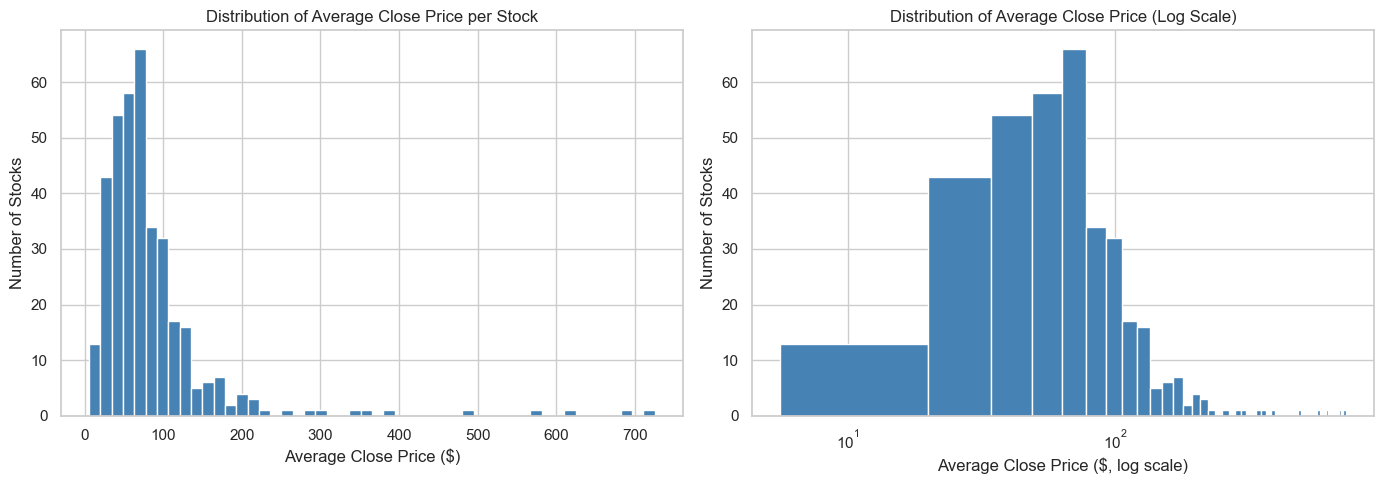

=== CLOSE PRICE SUMMARY ===
count    372.000000
mean      84.622121
std       81.677116
min        5.601863
25%       45.443319
50%       67.193693
75%       96.769539
max      725.403353
Name: avg_close, dtype: float64


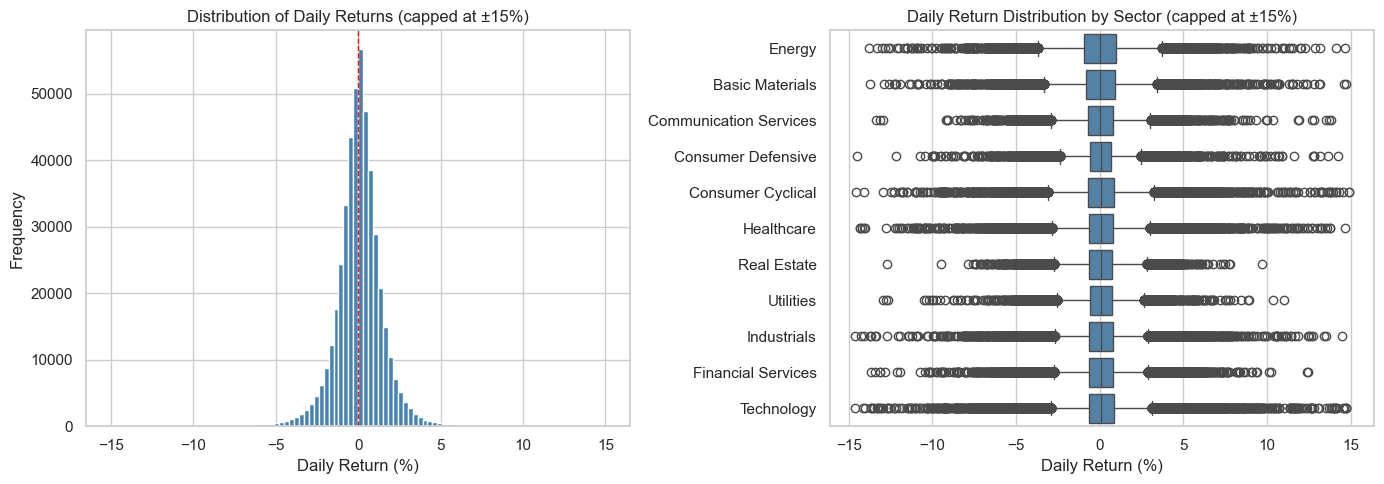


=== DAILY RETURN SUMMARY ===
count    460132.000000
mean          0.059449
std           1.534958
min         -62.618262
25%          -0.651603
50%           0.065969
75%           0.790306
max         100.951315
Name: daily_return, dtype: float64


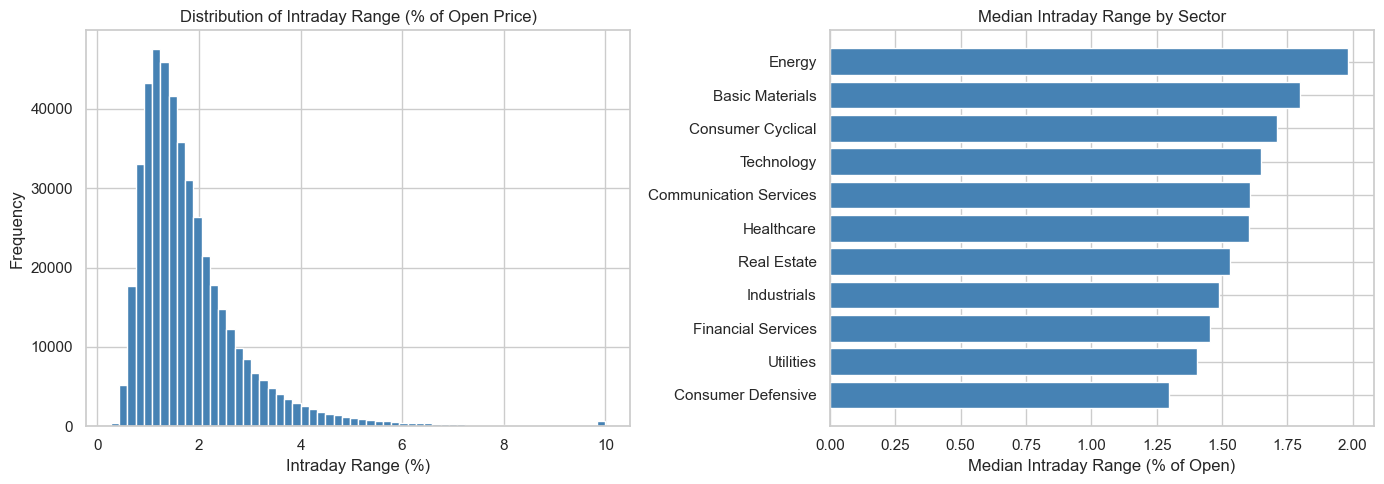


=== INTRADAY RANGE SUMMARY ===
count    460503.000000
mean          1.834325
std           1.128953
min           0.271429
25%           1.135030
50%           1.550203
75%           2.185472
max          51.582046
Name: intraday_range_pct, dtype: float64


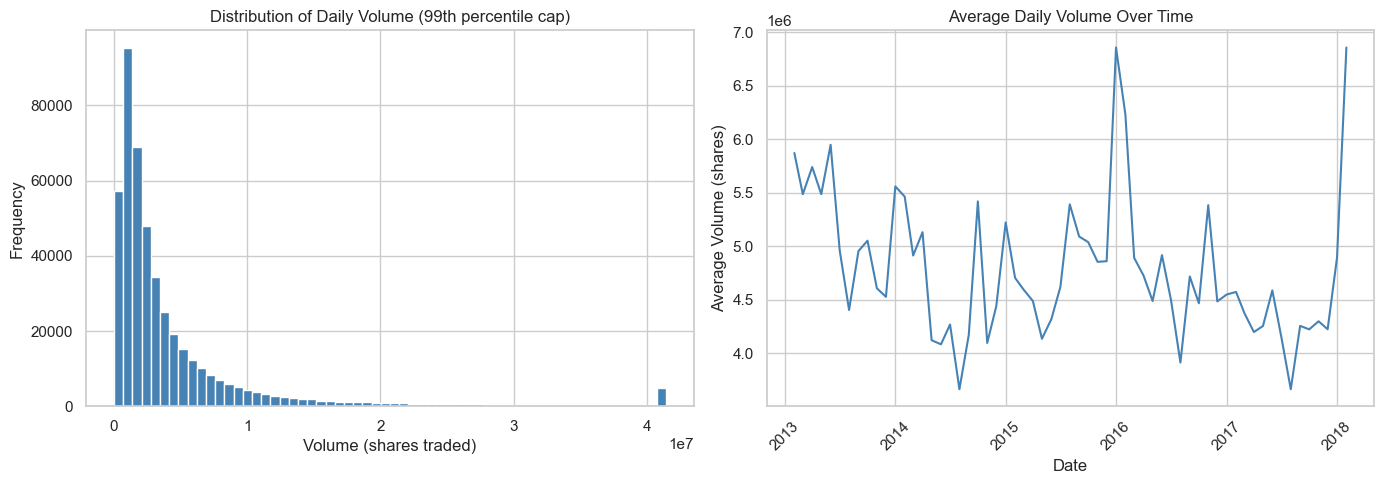


=== VOLUME SUMMARY ===
count    4.605030e+05
mean     4.753584e+06
std      9.513959e+06
min      7.932000e+03
25%      1.101418e+06
50%      2.188674e+06
75%      4.733958e+06
max      6.182376e+08
Name: volume, dtype: float64


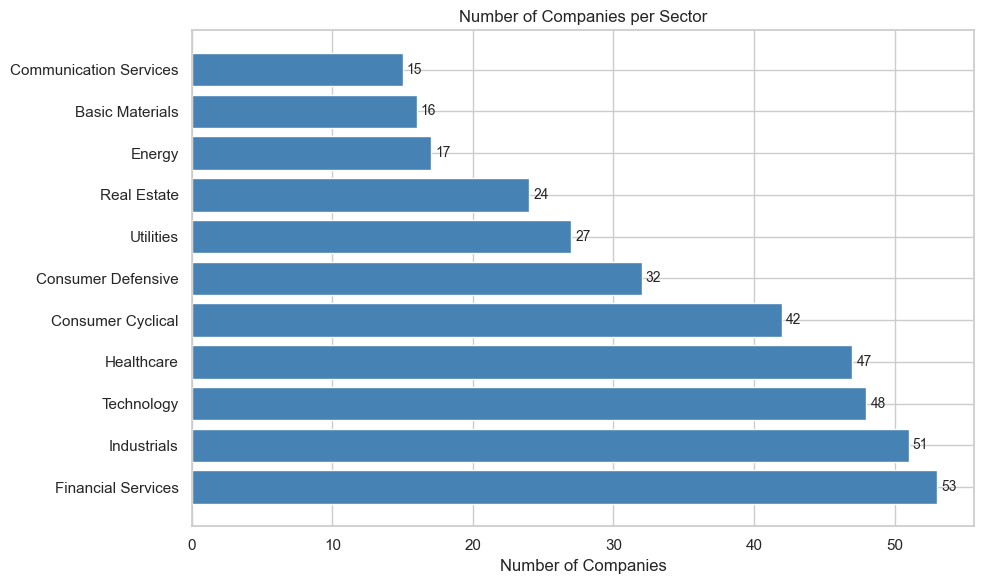

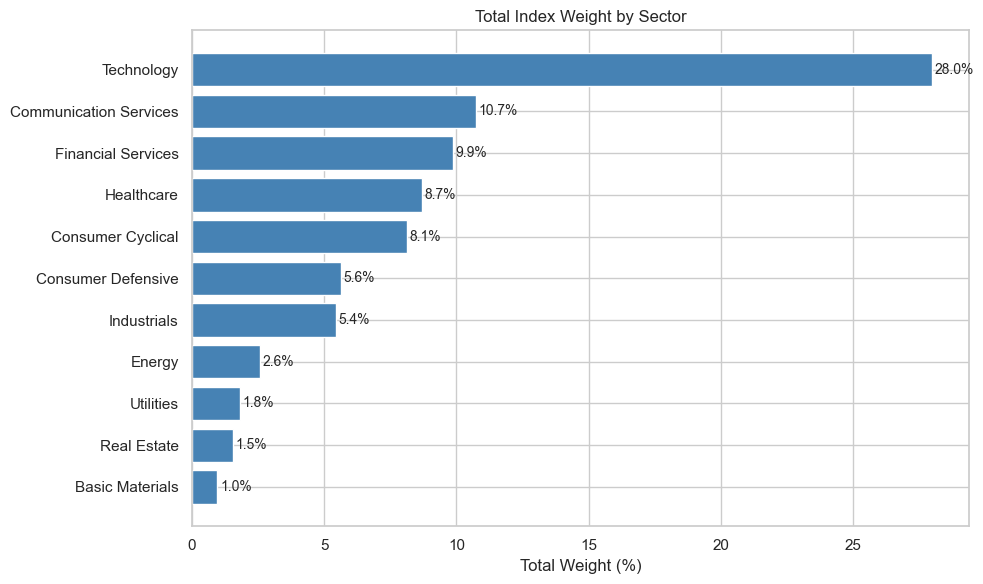


=== SECTOR WEIGHT SUMMARY ===
Sector
Technology                27.98
Communication Services    10.73
Financial Services         9.88
Healthcare                 8.69
Consumer Cyclical          8.14
Consumer Defensive         5.63
Industrials                5.44
Energy                     2.58
Utilities                  1.81
Real Estate                1.54
Basic Materials            0.97
Name: Weight, dtype: float64


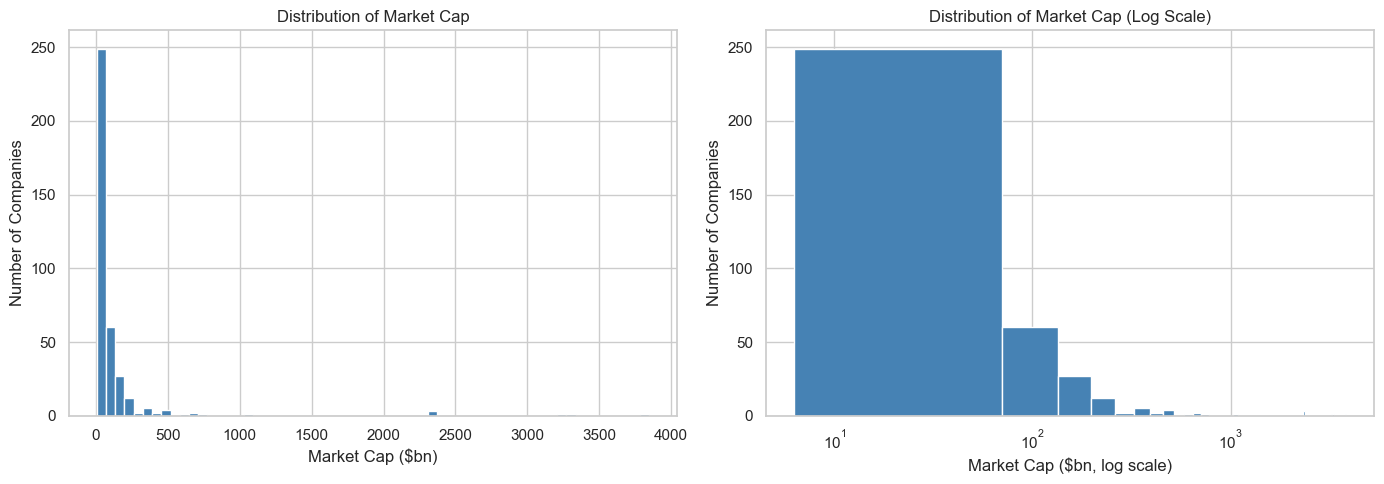


=== MARKET CAP SUMMARY ($bn) ===
count     372.000000
mean      124.609298
std       382.165949
min         6.260526
25%        20.856307
50%        42.159184
75%        85.282720
max      3846.819807
Name: Marketcap_bn, dtype: float64

Top 10 companies by market cap:
 Name                 Sector  Marketcap_bn
 AAPL             Technology   3846.819807
 NVDA             Technology   3298.803057
 MSFT             Technology   3246.068597
 AMZN      Consumer Cyclical   2365.033808
GOOGL Communication Services   2351.625142
 GOOG Communication Services   2351.623045
 AVGO             Technology   1031.217349
  WMT     Consumer Defensive    740.999889
  LLY             Healthcare    690.458853
  JPM     Financial Services    668.924838


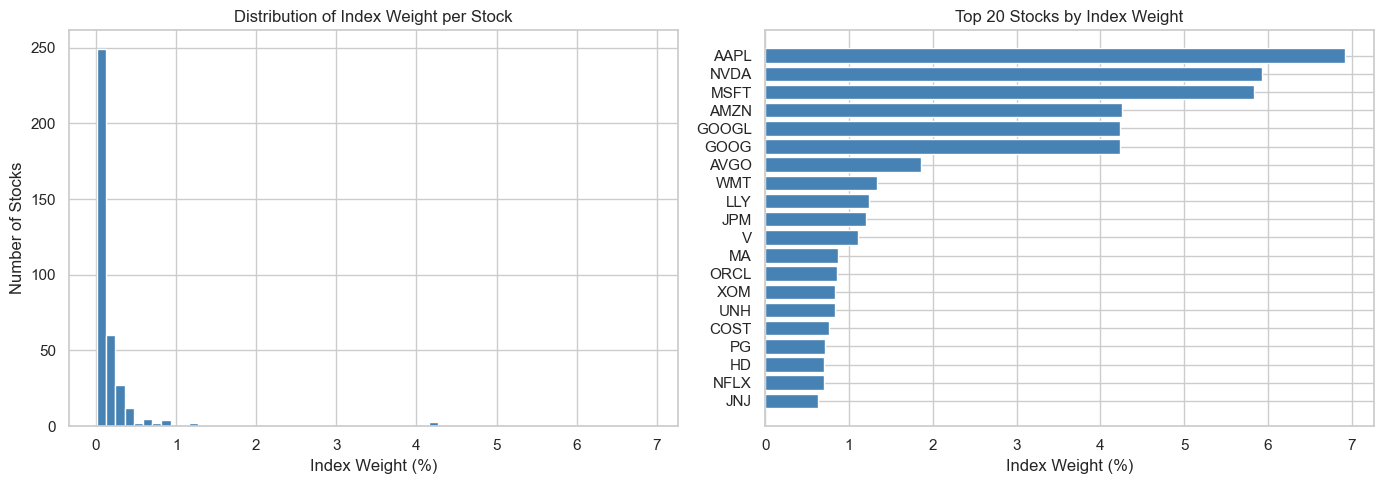


=== INDEX WEIGHT SUMMARY ===
Top 10 holdings account for 37.0% of the index
Top 20 holdings account for 45.0% of the index
 Name                 Sector   Weight
 AAPL             Technology 0.069209
 NVDA             Technology 0.059350
 MSFT             Technology 0.058401
 AMZN      Consumer Cyclical 0.042550
GOOGL Communication Services 0.042309
 GOOG Communication Services 0.042309
 AVGO             Technology 0.018553
  WMT     Consumer Defensive 0.013332
  LLY             Healthcare 0.012422
  JPM     Financial Services 0.012035


In [ ]:
# =============================================================
# Section 3: Univariate Analysis
# =============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# 1. Close price distribution

# Using df_all — distribution of price is valid for all tickers
# We take one row per ticker to avoid the same stock dominating

price_snapshot = df_all.groupby('Name')['close'].mean().reset_index()
price_snapshot.columns = ['Name', 'avg_close']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(price_snapshot['avg_close'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Average Close Price per Stock')
axes[0].set_xlabel('Average Close Price ($)')
axes[0].set_ylabel('Number of Stocks')

# Log scale version — better for skewed financial data
axes[1].hist(price_snapshot['avg_close'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Distribution of Average Close Price (Log Scale)')
axes[1].set_xlabel('Average Close Price ($, log scale)')
axes[1].set_ylabel('Number of Stocks')

plt.tight_layout()
plt.savefig('univariate_close_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== CLOSE PRICE SUMMARY ===")
print(price_snapshot['avg_close'].describe())

# 2. Daily return distribution

# Cap at +/- 15% to avoid extreme move artefacts dominating the chart
returns_capped = df_all['daily_return'].dropna().clip(-15, 15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(returns_capped, bins=100, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of Daily Returns (capped at ±15%)')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')

# By sector — box plot of daily returns
sector_order = df_all.groupby('Sector')['daily_return'].median().sort_values().index
sns.boxplot(data=df_all[df_all['daily_return'].between(-15, 15)],
            x='daily_return', y='Sector', order=sector_order,
            ax=axes[1], color='steelblue')
axes[1].set_title('Daily Return Distribution by Sector (capped at ±15%)')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('univariate_daily_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== DAILY RETURN SUMMARY ===")
print(df_all['daily_return'].dropna().describe())

# 3. Intraday range distribution

df_all['intraday_range'] = df_all['high'] - df_all['low']
df_all['intraday_range_pct'] = (df_all['intraday_range'] / df_all['open']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_all['intraday_range_pct'].clip(0, 10), bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Intraday Range (% of Open Price)')
axes[0].set_xlabel('Intraday Range (%)')
axes[0].set_ylabel('Frequency')

sector_range = df_all.groupby('Sector')['intraday_range_pct'].median().sort_values()
axes[1].barh(sector_range.index, sector_range.values, color='steelblue')
axes[1].set_title('Median Intraday Range by Sector')
axes[1].set_xlabel('Median Intraday Range (% of Open)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('univariate_intraday_range.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== INTRADAY RANGE SUMMARY ===")
print(df_all['intraday_range_pct'].describe())

# 4. Volume distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_all['volume'].clip(upper=df_all['volume'].quantile(0.99)),
             bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Daily Volume (99th percentile cap)')
axes[0].set_xlabel('Volume (shares traded)')
axes[0].set_ylabel('Frequency')

# Volume over time — monthly average
df_all['month'] = df_all['date'].dt.to_period('M')
monthly_volume = df_all.groupby('month')['volume'].mean().reset_index()
monthly_volume['month'] = monthly_volume['month'].dt.to_timestamp()

axes[1].plot(monthly_volume['month'], monthly_volume['volume'],
             color='steelblue', linewidth=1.5)
axes[1].set_title('Average Daily Volume Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Volume (shares)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('univariate_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== VOLUME SUMMARY ===")
print(df_all['volume'].describe())

# 5. Companies per sector

sector_counts = df_all.drop_duplicates(subset='Name')['Sector'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sector_counts.index, sector_counts.values, color='steelblue')
ax.set_title('Number of Companies per Sector')
ax.set_xlabel('Number of Companies')
ax.set_ylabel('')

for i, v in enumerate(sector_counts.values):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('univariate_sector_counts.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Index weight per sector

sector_weight = (df_all.drop_duplicates(subset='Name')
                 .groupby('Sector')['Weight']
                 .sum()
                 .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sector_weight.index, sector_weight.values * 100, color='steelblue')
ax.set_title('Total Index Weight by Sector')
ax.set_xlabel('Total Weight (%)')
ax.set_ylabel('')

for i, v in enumerate(sector_weight.values):
    ax.text(v * 100 + 0.1, i, f'{v*100:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('univariate_sector_weight.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== SECTOR WEIGHT SUMMARY ===")
print((sector_weight * 100).round(2).sort_values(ascending=False))

# 7. Market cap distribution

marketcap_snapshot = df_all.drop_duplicates(subset='Name')[['Name', 'Sector', 'Marketcap_bn']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(marketcap_snapshot['Marketcap_bn'], bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Market Cap')
axes[0].set_xlabel('Market Cap ($bn)')
axes[0].set_ylabel('Number of Companies')

axes[1].hist(marketcap_snapshot['Marketcap_bn'], bins=60,
             color='steelblue', edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Distribution of Market Cap (Log Scale)')
axes[1].set_xlabel('Market Cap ($bn, log scale)')
axes[1].set_ylabel('Number of Companies')

plt.tight_layout()
plt.savefig('univariate_marketcap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== MARKET CAP SUMMARY ($bn) ===")
print(marketcap_snapshot['Marketcap_bn'].describe())
print(f"\nTop 10 companies by market cap:")
print(marketcap_snapshot.sort_values('Marketcap_bn', ascending=False)
      [['Name', 'Sector', 'Marketcap_bn']].head(10).to_string(index=False))

# 8. Index weight distribution

weight_snapshot = df_all.drop_duplicates(subset='Name')[['Name', 'Sector', 'Weight']].sort_values(
    'Weight', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(weight_snapshot['Weight'] * 100, bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Index Weight per Stock')
axes[0].set_xlabel('Index Weight (%)')
axes[0].set_ylabel('Number of Stocks')

# Top 20 holdings by weight
top20 = weight_snapshot.head(20)
axes[1].barh(top20['Name'][::-1], top20['Weight'][::-1] * 100, color='steelblue')
axes[1].set_title('Top 20 Stocks by Index Weight')
axes[1].set_xlabel('Index Weight (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('univariate_weight.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== INDEX WEIGHT SUMMARY ===")
print(f"Top 10 holdings account for {weight_snapshot.head(10)['Weight'].sum()*100:.1f}% of the index")
print(f"Top 20 holdings account for {weight_snapshot.head(20)['Weight'].sum()*100:.1f}% of the index")
print(weight_snapshot.head(10)[['Name', 'Sector', 'Weight']].to_string(index=False))

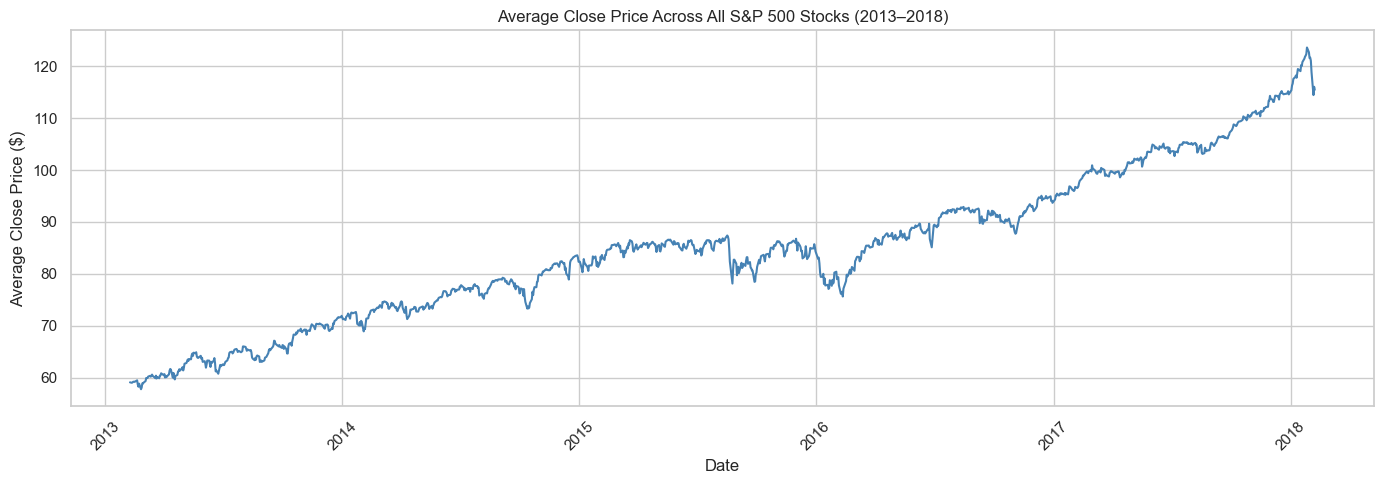

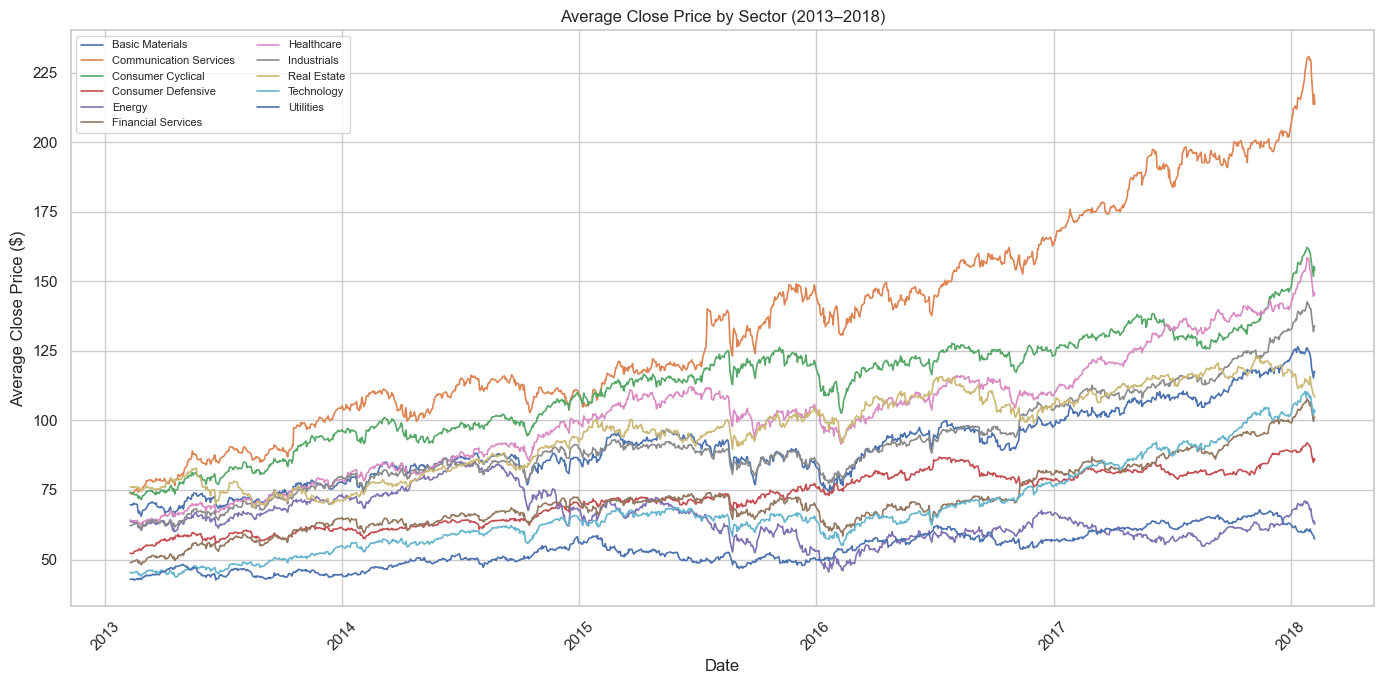

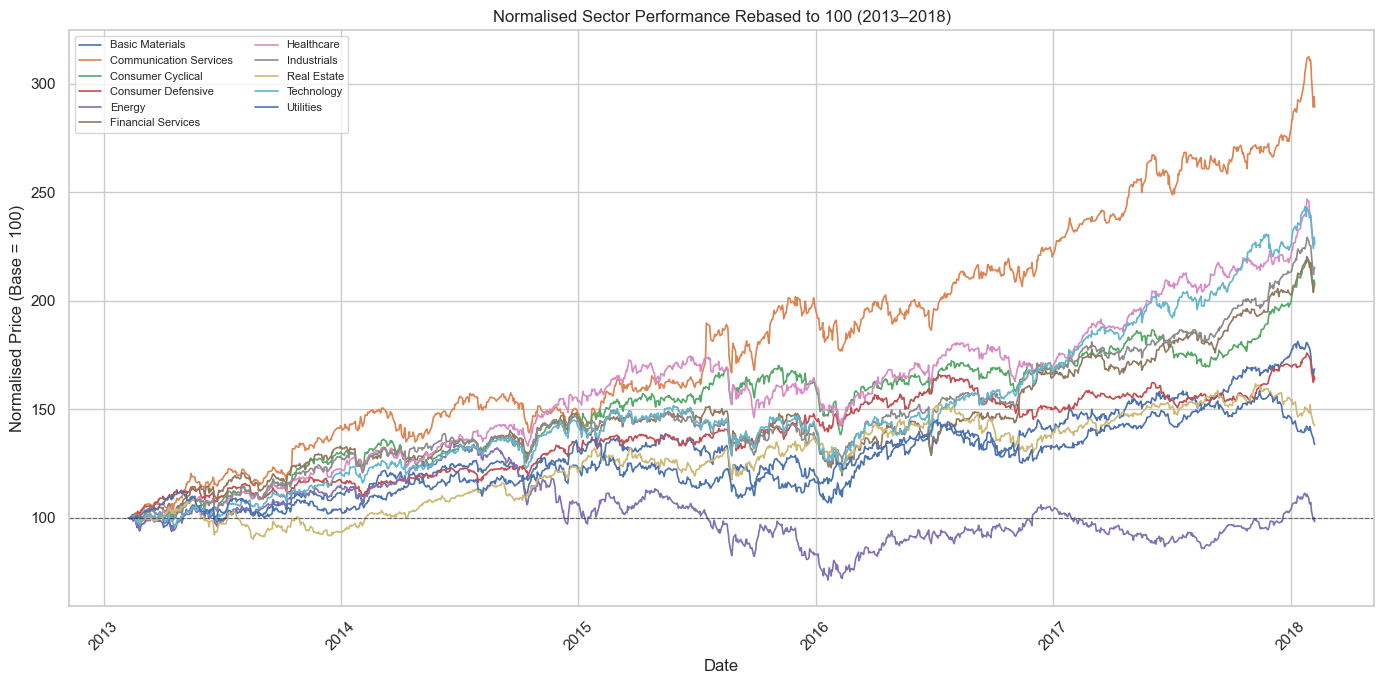

=== SECTOR TOTAL RETURN (2013–2018) ===
Sector
Communication Services    189.4
Technology                127.1
Healthcare                126.2
Industrials               115.5
Consumer Cyclical         107.7
Financial Services        106.9
Basic Materials            68.6
Consumer Defensive         63.9
Real Estate                42.5
Utilities                  33.9
Energy                     -1.7


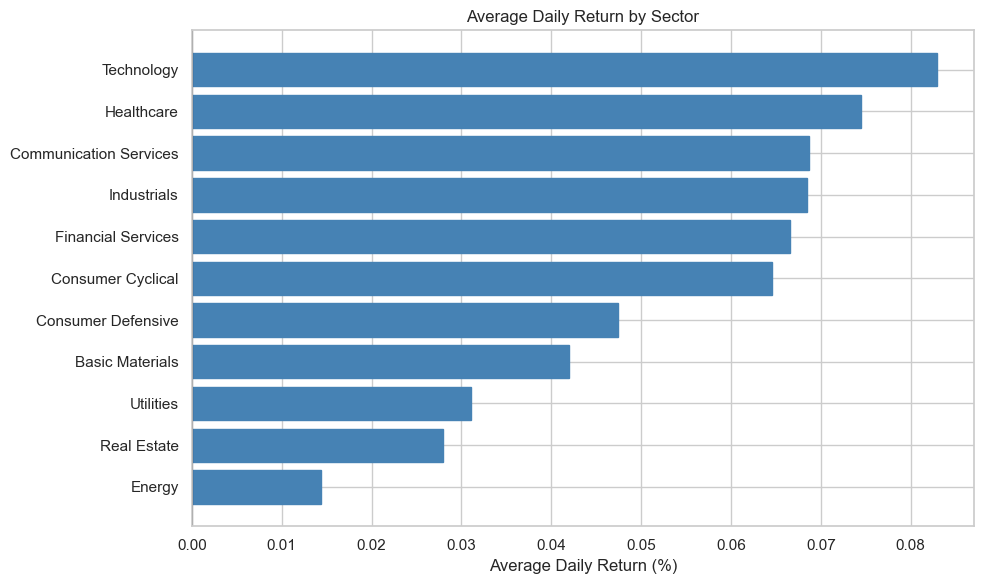


=== AVERAGE DAILY RETURN BY SECTOR ===
Sector
Energy                    0.0144
Real Estate               0.0280
Utilities                 0.0311
Basic Materials           0.0420
Consumer Defensive        0.0474
Consumer Cyclical         0.0646
Financial Services        0.0666
Industrials               0.0685
Communication Services    0.0687
Healthcare                0.0744
Technology                0.0829


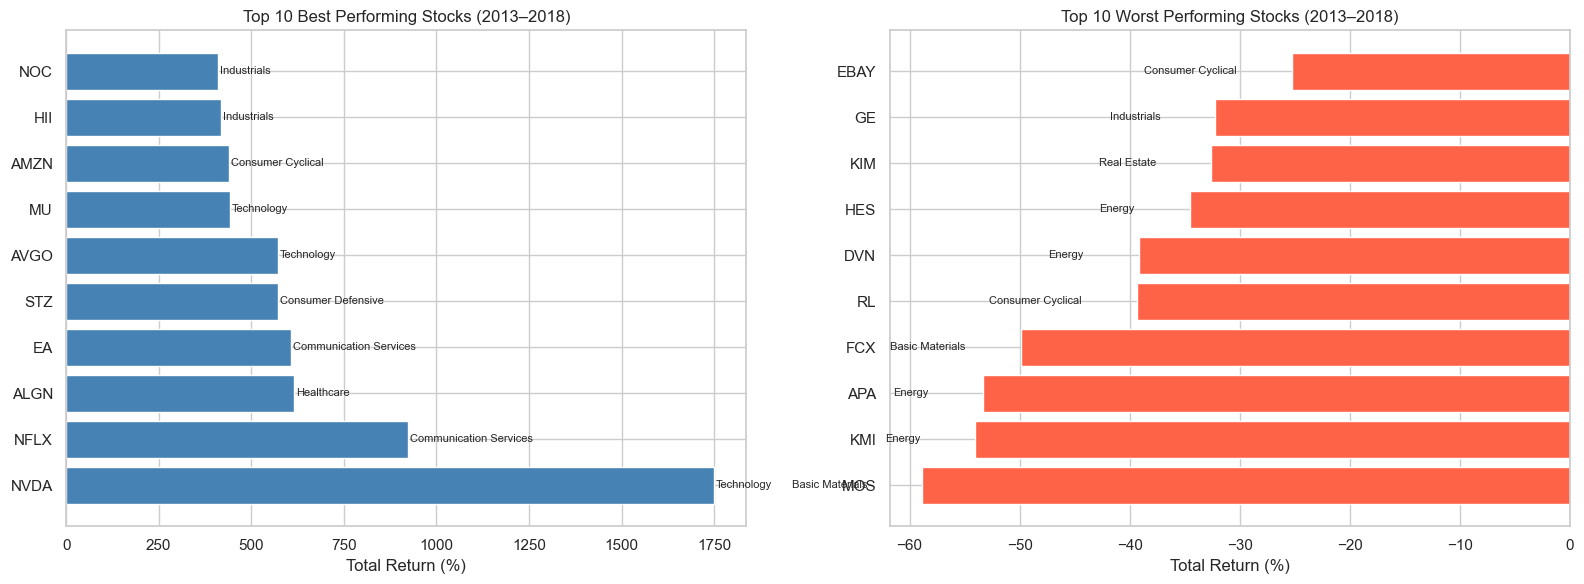

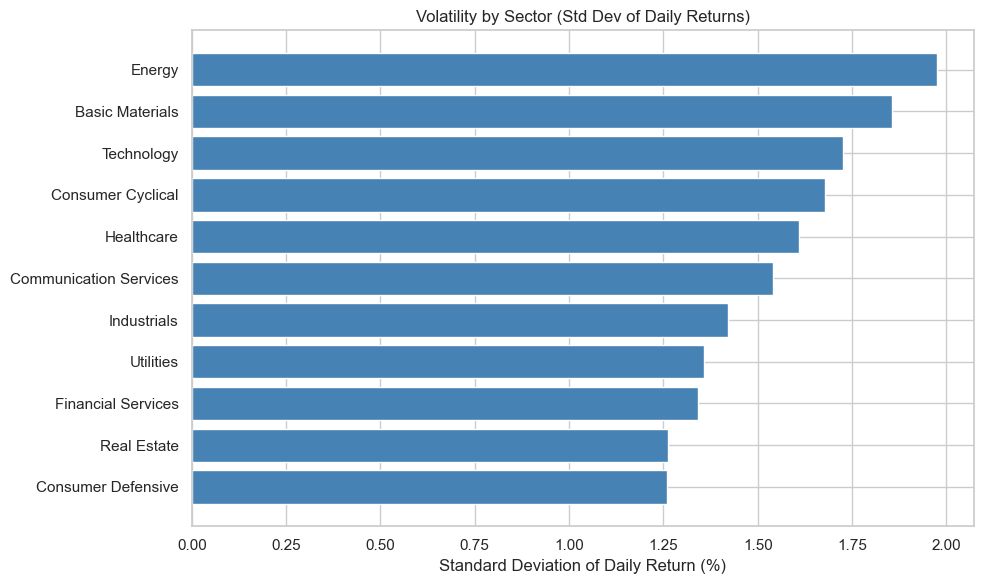


=== VOLATILITY BY SECTOR ===
Sector
Consumer Defensive        1.2605
Real Estate               1.2612
Financial Services        1.3424
Utilities                 1.3586
Industrials               1.4226
Communication Services    1.5412
Healthcare                1.6087
Consumer Cyclical         1.6773
Technology                1.7266
Basic Materials           1.8553
Energy                    1.9746


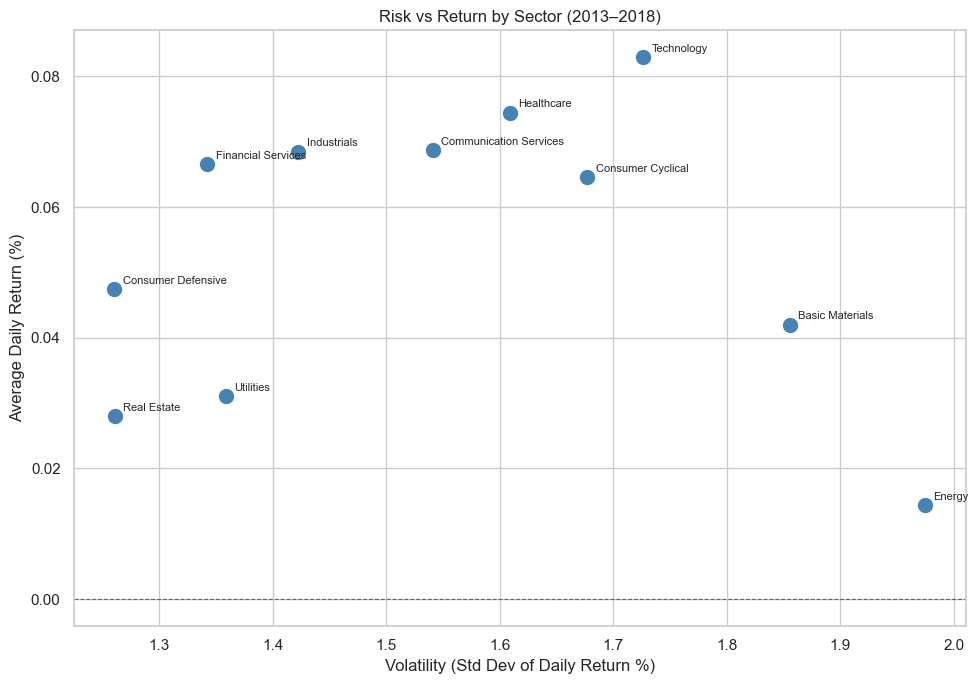

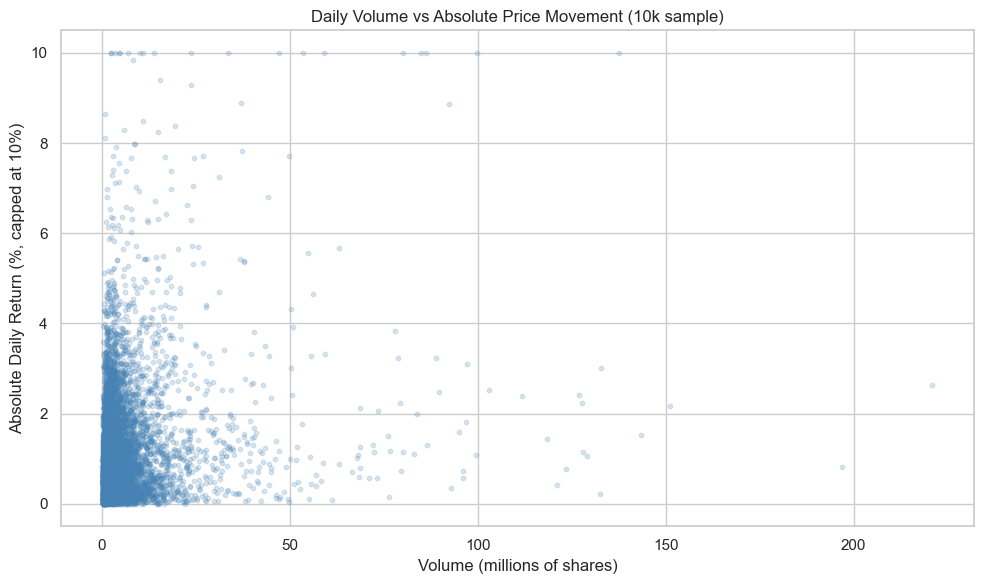


=== VOLUME VS RETURN CORRELATION ===
Correlation: 0.2143


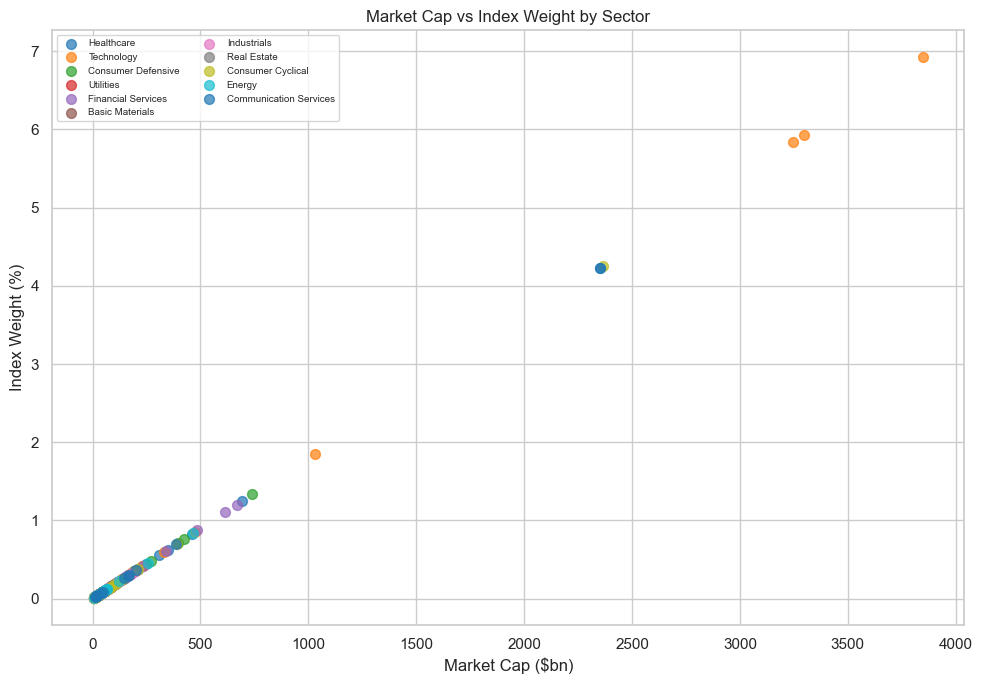


=== MARKET CAP VS WEIGHT CORRELATION ===
Correlation: 1.0000


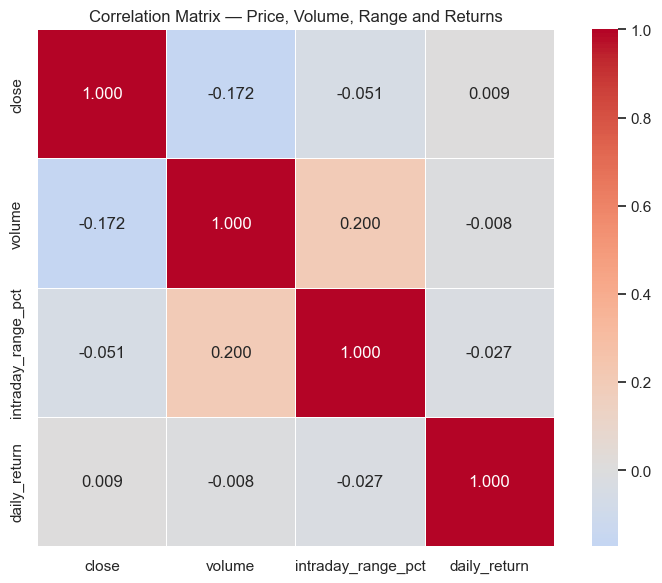


=== CORRELATION MATRIX ===
                    close  volume  intraday_range_pct  daily_return
close               1.000  -0.172              -0.051         0.009
volume             -0.172   1.000               0.200        -0.008
intraday_range_pct -0.051   0.200               1.000        -0.027
daily_return        0.009  -0.008              -0.027         1.000


In [ ]:
# =============================================================
# Section 4: Bivariate / Multivariate Analysis
# =============================================================

# 1. Overall market price trend over time

# Using df_full — consistent set of tickers across the full period
daily_avg_price = df_full.groupby('date')['close'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_avg_price['date'], daily_avg_price['close'],
        color='steelblue', linewidth=1.5)
ax.set_title('Average Close Price Across All S&P 500 Stocks (2013–2018)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Close Price ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('bivariate_market_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Sector price trends over time

# Using df_full — comparing sectors across the full period
sector_price = df_full.groupby(['date', 'Sector'])['close'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
for sector in sector_price['Sector'].unique():
    data = sector_price[sector_price['Sector'] == sector]
    ax.plot(data['date'], data['close'], linewidth=1.2, label=sector)

ax.set_title('Average Close Price by Sector (2013–2018)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Close Price ($)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('bivariate_sector_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Normalised sector performance (rebased to 100)

# Rebasing to 100 at the start date makes sectors comparable
# regardless of their absolute price levels
sector_price_pivot = sector_price.pivot(index='date', columns='Sector', values='close')
sector_price_normalised = sector_price_pivot.div(sector_price_pivot.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))
for sector in sector_price_normalised.columns:
    ax.plot(sector_price_normalised.index, sector_price_normalised[sector],
            linewidth=1.2, label=sector)

ax.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Normalised Sector Performance Rebased to 100 (2013–2018)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised Price (Base = 100)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('bivariate_sector_normalised.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== SECTOR TOTAL RETURN (2013–2018) ===")
total_return = (sector_price_normalised.iloc[-1] - 100).sort_values(ascending=False)
print(total_return.round(1).to_string())

# 4. Average daily return by sector

# Using df_all — daily returns are valid for all tickers
sector_returns = (df_all.groupby('Sector')['daily_return']
                  .mean()
                  .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sector_returns.index, sector_returns.values, color='steelblue')

# Colour negative bars differently
for bar, val in zip(bars, sector_returns.values):
    bar.set_color('steelblue' if val >= 0 else 'tomato')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Average Daily Return by Sector')
ax.set_xlabel('Average Daily Return (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('bivariate_sector_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== AVERAGE DAILY RETURN BY SECTOR ===")
print(sector_returns.round(4).to_string())

# 5. Best and worst performing stocks over the full period

# Using df_full only — need complete coverage to compare fairly
stock_performance = (df_full.groupby('Name')
                     .apply(lambda x: (x.sort_values('date')['close'].iloc[-1] /
                                       x.sort_values('date')['close'].iloc[0] - 1) * 100)
                     .reset_index())
stock_performance.columns = ['Name', 'total_return_pct']

# Merge sector back in
stock_performance = stock_performance.merge(
    df_full[['Name', 'Sector']].drop_duplicates(), on='Name')

top10 = stock_performance.nlargest(10, 'total_return_pct')
bottom10 = stock_performance.nsmallest(10, 'total_return_pct')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['Name'], top10['total_return_pct'], color='steelblue')
axes[0].set_title('Top 10 Best Performing Stocks (2013–2018)')
axes[0].set_xlabel('Total Return (%)')
for i, (val, sector) in enumerate(zip(top10['total_return_pct'], top10['Sector'])):
    axes[0].text(val + 5, i, sector, va='center', fontsize=8)

axes[1].barh(bottom10['Name'], bottom10['total_return_pct'], color='tomato')
axes[1].set_title('Top 10 Worst Performing Stocks (2013–2018)')
axes[1].set_xlabel('Total Return (%)')
for i, (val, sector) in enumerate(zip(bottom10['total_return_pct'], bottom10['Sector'])):
    axes[1].text(val - 5, i, sector, va='center', fontsize=8, ha='right')

plt.tight_layout()
plt.savefig('bivariate_best_worst_stocks.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Volatility by sector

# Using df_all — volatility measured as std of daily returns
sector_volatility = (df_all.groupby('Sector')['daily_return']
                     .std()
                     .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sector_volatility.index, sector_volatility.values, color='steelblue')
ax.set_title('Volatility by Sector (Std Dev of Daily Returns)')
ax.set_xlabel('Standard Deviation of Daily Return (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('bivariate_sector_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== VOLATILITY BY SECTOR ===")
print(sector_volatility.round(4).to_string())

# 7. Return vs volatility by sector (risk-return plot)

sector_stats = pd.DataFrame({
    'avg_return': df_all.groupby('Sector')['daily_return'].mean(),
    'volatility': df_all.groupby('Sector')['daily_return'].std()
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(sector_stats['volatility'], sector_stats['avg_return'],
           color='steelblue', s=100, zorder=3)

for _, row in sector_stats.iterrows():
    ax.annotate(row['Sector'], (row['volatility'], row['avg_return']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Risk vs Return by Sector (2013–2018)')
ax.set_xlabel('Volatility (Std Dev of Daily Return %)')
ax.set_ylabel('Average Daily Return (%)')
plt.tight_layout()
plt.savefig('bivariate_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. Volume vs absolute daily price movement

# Sample to avoid overplotting — 10,000 random rows
sample = df_all[['volume', 'daily_return']].dropna().sample(10000, random_state=42)
sample['abs_return'] = sample['daily_return'].abs()
sample['volume_m'] = sample['volume'] / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['volume_m'], sample['abs_return'].clip(upper=10),
           alpha=0.2, color='steelblue', s=10)
ax.set_title('Daily Volume vs Absolute Price Movement (10k sample)')
ax.set_xlabel('Volume (millions of shares)')
ax.set_ylabel('Absolute Daily Return (%, capped at 10%)')
plt.tight_layout()
plt.savefig('bivariate_volume_vs_return.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== VOLUME VS RETURN CORRELATION ===")
print(f"Correlation: {sample['volume_m'].corr(sample['abs_return']):.4f}")

# 9. Market cap vs index weight

cap_weight = df_all.drop_duplicates(subset='Name')[['Name', 'Sector', 'Marketcap_bn', 'Weight']]

fig, ax = plt.subplots(figsize=(10, 7))
sectors = cap_weight['Sector'].unique()
colours = plt.cm.tab10.colors

for i, sector in enumerate(sectors):
    subset = cap_weight[cap_weight['Sector'] == sector]
    ax.scatter(subset['Marketcap_bn'], subset['Weight'] * 100,
               label=sector, color=colours[i % len(colours)], s=50, alpha=0.7)

ax.set_title('Market Cap vs Index Weight by Sector')
ax.set_xlabel('Market Cap ($bn)')
ax.set_ylabel('Index Weight (%)')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('bivariate_marketcap_vs_weight.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== MARKET CAP VS WEIGHT CORRELATION ===")
print(f"Correlation: {cap_weight['Marketcap_bn'].corr(cap_weight['Weight']):.4f}")

# 10. Correlation heatmap

# Numeric variables worth correlating
corr_cols = ['close', 'volume', 'intraday_range_pct', 'daily_return']
corr_matrix = df_all[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, square=True,
            linewidths=0.5)
ax.set_title('Correlation Matrix — Price, Volume, Range and Returns')
plt.tight_layout()
plt.savefig('bivariate_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== CORRELATION MATRIX ===")
print(corr_matrix.round(3))

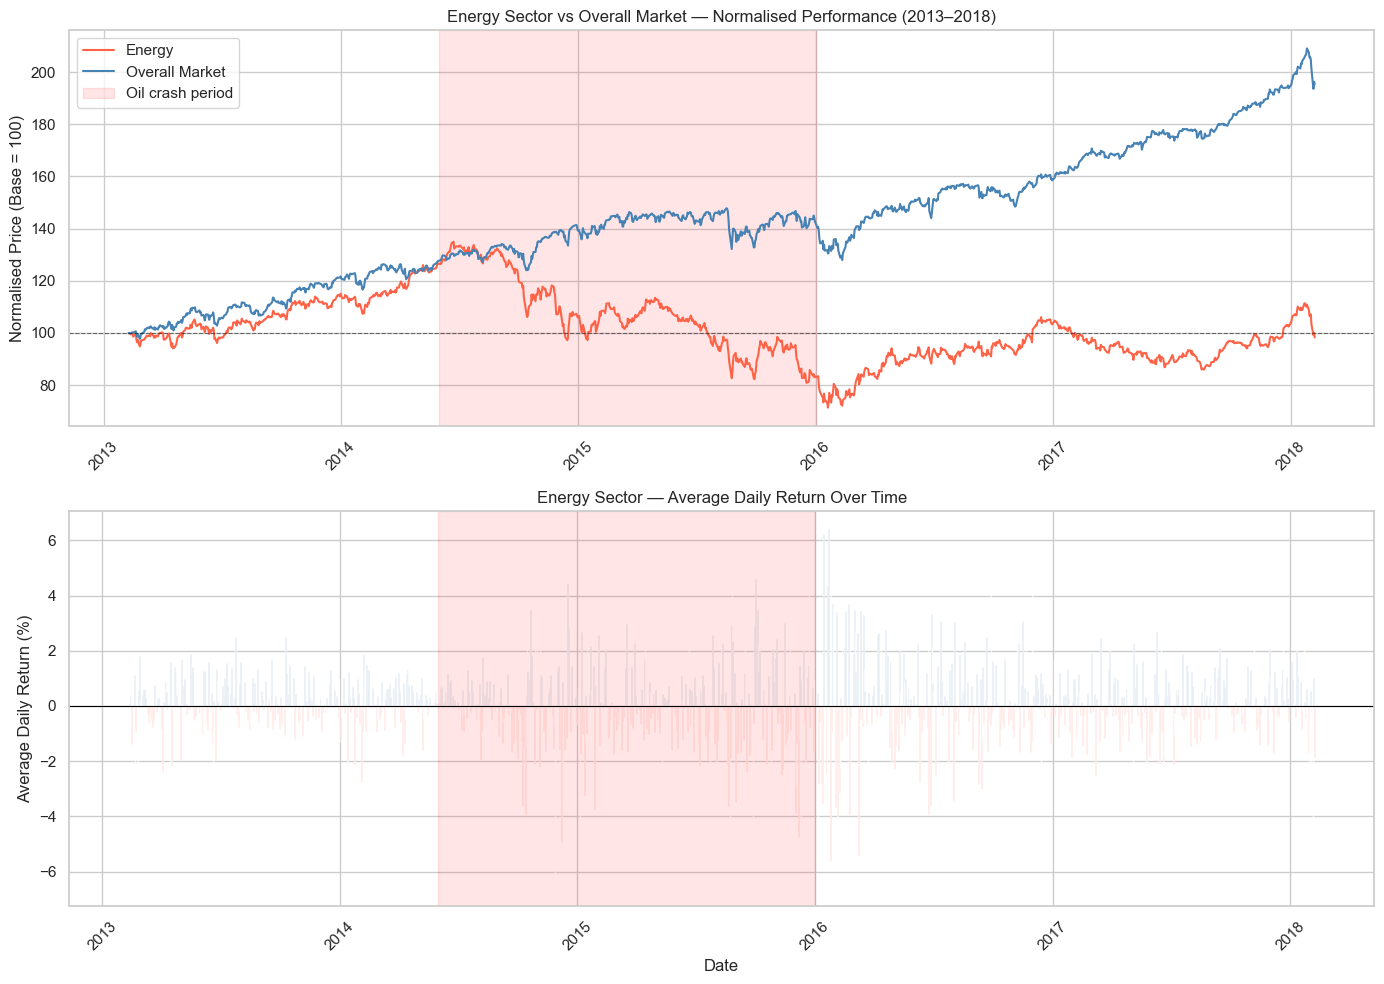

=== ENERGY PERFORMANCE DURING OIL CRASH ===
Energy price at crash start: $80.60
Energy price at crash end:   $53.15
Energy decline during crash: -34.1%


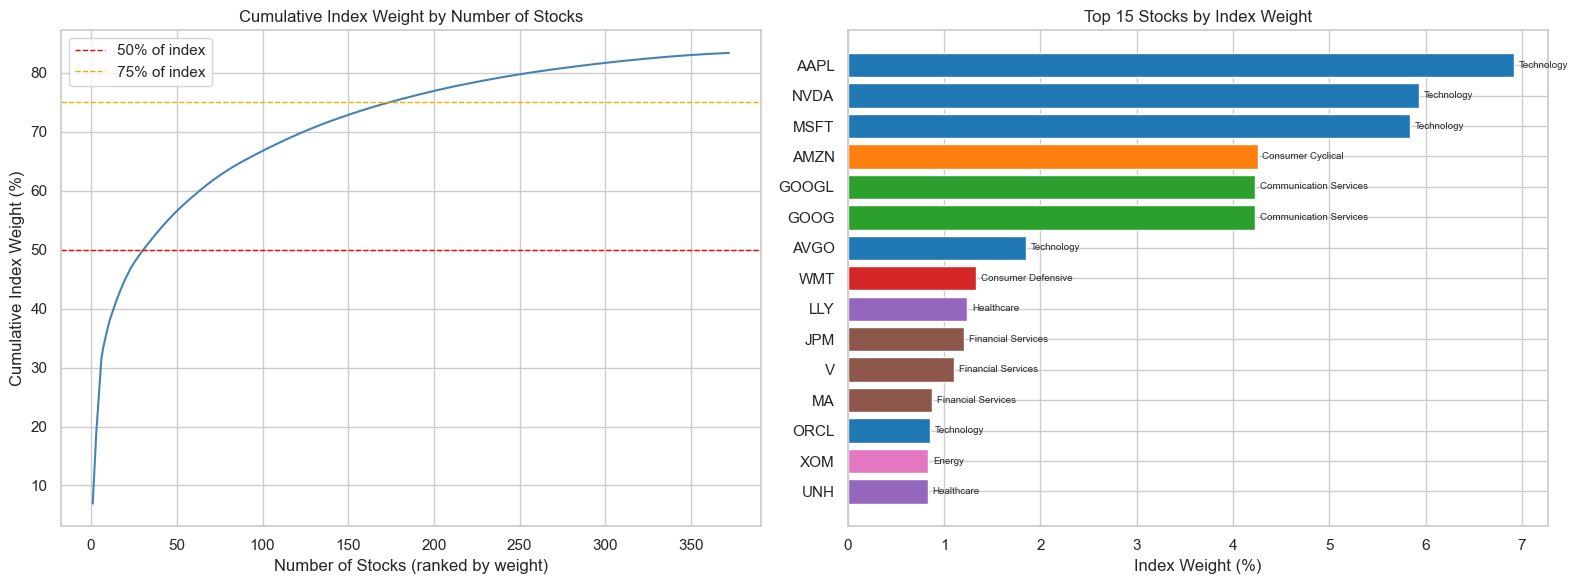


=== INDEX CONCENTRATION ===
Stocks needed to reach 50% of index: 30
Stocks needed to reach 75% of index: 173
Top 5 stocks account for: 27.2% of index
Top 10 stocks account for: 37.0% of index
Bottom 100 stocks account for: 2.7% of index


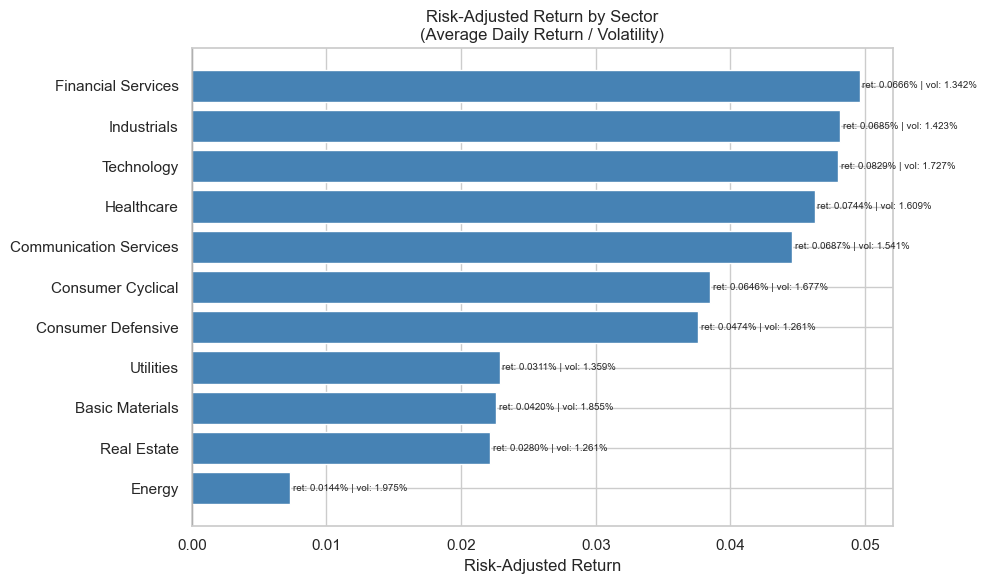


=== RISK-ADJUSTED RETURN BY SECTOR ===
                Sector  avg_return  volatility  risk_adjusted_return
    Financial Services      0.0666      1.3424                0.0496
           Industrials      0.0685      1.4226                0.0481
            Technology      0.0829      1.7266                0.0480
            Healthcare      0.0744      1.6087                0.0463
Communication Services      0.0687      1.5412                0.0446
     Consumer Cyclical      0.0646      1.6773                0.0385
    Consumer Defensive      0.0474      1.2605                0.0376
             Utilities      0.0311      1.3586                0.0229
       Basic Materials      0.0420      1.8553                0.0226
           Real Estate      0.0280      1.2612                0.0222
                Energy      0.0144      1.9746                0.0073


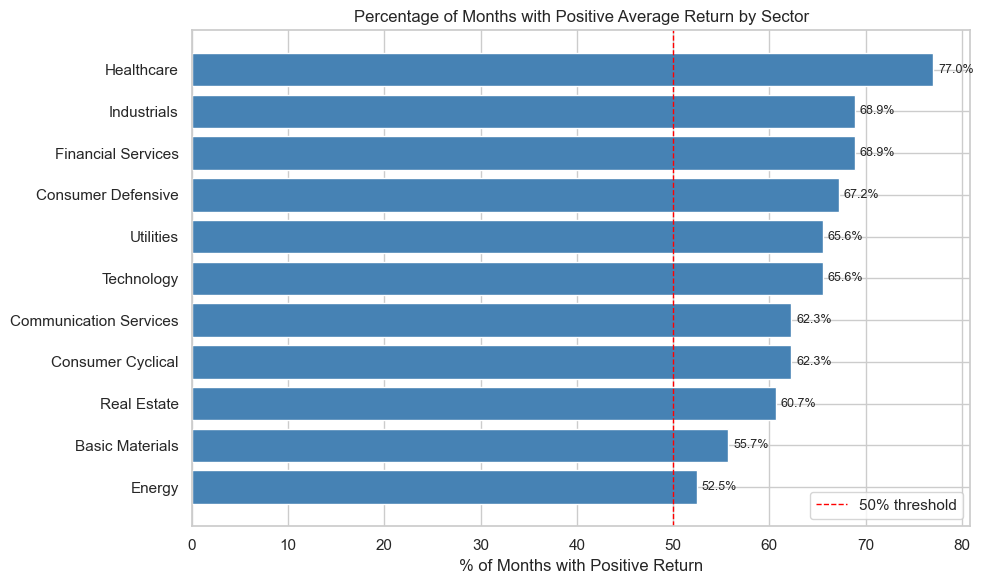


=== SECTOR CONSISTENCY ===
                Sector  pct_positive_months
            Healthcare            77.049180
    Financial Services            68.852459
           Industrials            68.852459
    Consumer Defensive            67.213115
            Technology            65.573770
             Utilities            65.573770
     Consumer Cyclical            62.295082
Communication Services            62.295082
           Real Estate            60.655738
       Basic Materials            55.737705
                Energy            52.459016


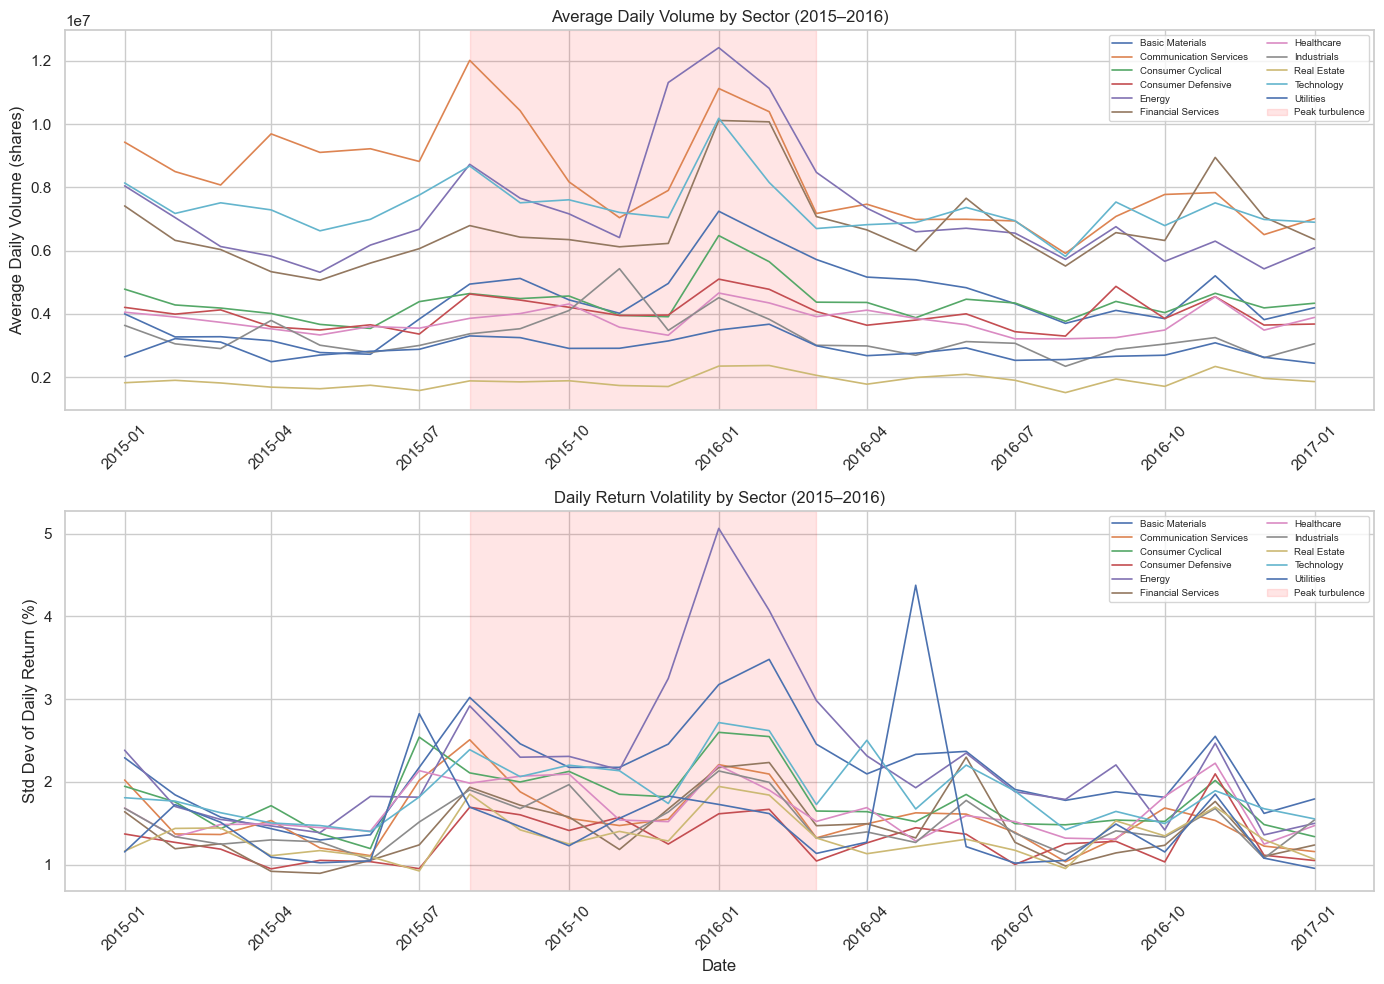


=== VOLATILITY INCREASE BY SECTOR DURING 2015–2016 TURBULENCE ===
Sector
Energy                    80.8
Basic Materials           56.4
Financial Services        49.3
Technology                35.1
Consumer Defensive        32.8
Industrials               29.6
Real Estate               29.2
Consumer Cyclical         22.2
Communication Services    20.3
Healthcare                18.1
Utilities                  3.4


In [ ]:
# =============================================================
# Section 5: Domain Insights
# =============================================================

# 1. The Energy story — zooming into the oil crash

# Using df_full — need consistent tickers to isolate sector trend
energy_prices = df_full[df_full['Sector'] == 'Energy'].groupby('date')['close'].mean().reset_index()
market_prices = df_full.groupby('date')['close'].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Energy vs overall market normalised
energy_norm = energy_prices.set_index('date')['close'] / energy_prices['close'].iloc[0] * 100
market_norm = market_prices.set_index('date')['close'] / market_prices['close'].iloc[0] * 100

axes[0].plot(energy_norm.index, energy_norm.values, color='tomato', linewidth=1.5, label='Energy')
axes[0].plot(market_norm.index, market_norm.values, color='steelblue', linewidth=1.5, label='Overall Market')
axes[0].axvspan(pd.Timestamp('2014-06-01'), pd.Timestamp('2016-01-01'),
                alpha=0.1, color='red', label='Oil crash period')
axes[0].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title('Energy Sector vs Overall Market — Normalised Performance (2013–2018)')
axes[0].set_ylabel('Normalised Price (Base = 100)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Energy daily returns over time
energy_returns = df_full[df_full['Sector'] == 'Energy'].groupby('date')['daily_return'].mean().reset_index()
axes[1].bar(energy_returns['date'], energy_returns['daily_return'],
            color=energy_returns['daily_return'].apply(lambda x: 'steelblue' if x >= 0 else 'tomato'),
            width=1, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvspan(pd.Timestamp('2014-06-01'), pd.Timestamp('2016-01-01'),
                alpha=0.1, color='red')
axes[1].set_title('Energy Sector — Average Daily Return Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Daily Return (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('domain_energy_story.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ENERGY PERFORMANCE DURING OIL CRASH ===")
crash_start = '2014-06-01'
crash_end = '2016-01-01'
energy_crash = energy_prices[(energy_prices['date'] >= crash_start) &
                              (energy_prices['date'] <= crash_end)]
print(f"Energy price at crash start: ${energy_crash['close'].iloc[0]:.2f}")
print(f"Energy price at crash end:   ${energy_crash['close'].iloc[-1]:.2f}")
print(f"Energy decline during crash: {((energy_crash['close'].iloc[-1] / energy_crash['close'].iloc[0]) - 1) * 100:.1f}%")

# 2. Index concentration — how much do the top stocks matter?

weight_snapshot = df_all.drop_duplicates(subset='Name')[['Name', 'Sector', 'Weight', 'Marketcap_bn']]
weight_snapshot = weight_snapshot.sort_values('Weight', ascending=False).reset_index(drop=True)
weight_snapshot['cumulative_weight'] = weight_snapshot['Weight'].cumsum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative weight curve
axes[0].plot(range(1, len(weight_snapshot) + 1),
             weight_snapshot['cumulative_weight'],
             color='steelblue', linewidth=1.5)
axes[0].axhline(50, color='red', linestyle='--', linewidth=1, label='50% of index')
axes[0].axhline(75, color='orange', linestyle='--', linewidth=1, label='75% of index')
axes[0].set_title('Cumulative Index Weight by Number of Stocks')
axes[0].set_xlabel('Number of Stocks (ranked by weight)')
axes[0].set_ylabel('Cumulative Index Weight (%)')
axes[0].legend()

# Top 15 stocks by weight coloured by sector
top15 = weight_snapshot.head(15)
sector_colour_map = {s: plt.cm.tab10.colors[i] for i, s in
                     enumerate(top15['Sector'].unique())}
colours = top15['Sector'].map(sector_colour_map)

bars = axes[1].barh(top15['Name'][::-1], top15['Weight'][::-1] * 100,
                     color=colours[::-1])
axes[1].set_title('Top 15 Stocks by Index Weight')
axes[1].set_xlabel('Index Weight (%)')

# Add sector labels
for i, (val, sector) in enumerate(zip(top15['Weight'][::-1] * 100,
                                       top15['Sector'][::-1])):
    axes[1].text(val + 0.05, i, sector, va='center', fontsize=7)

plt.tight_layout()
plt.savefig('domain_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

# How many stocks make up 50% of the index
stocks_for_50 = (weight_snapshot['cumulative_weight'] <= 50).sum()
stocks_for_75 = (weight_snapshot['cumulative_weight'] <= 75).sum()

print(f"\n=== INDEX CONCENTRATION ===")
print(f"Stocks needed to reach 50% of index: {stocks_for_50}")
print(f"Stocks needed to reach 75% of index: {stocks_for_75}")
print(f"Top 5 stocks account for: {weight_snapshot.head(5)['Weight'].sum()*100:.1f}% of index")
print(f"Top 10 stocks account for: {weight_snapshot.head(10)['Weight'].sum()*100:.1f}% of index")
print(f"Bottom 100 stocks account for: {weight_snapshot.tail(100)['Weight'].sum()*100:.1f}% of index")

# 3. Risk-adjusted return by sector

# Sharpe-like ratio — average daily return divided by volatility
# Higher = better return per unit of risk taken
sector_stats = pd.DataFrame({
    'avg_return': df_all.groupby('Sector')['daily_return'].mean(),
    'volatility': df_all.groupby('Sector')['daily_return'].std()
}).reset_index()

sector_stats['risk_adjusted_return'] = sector_stats['avg_return'] / sector_stats['volatility']
sector_stats = sector_stats.sort_values('risk_adjusted_return', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sector_stats['Sector'], sector_stats['risk_adjusted_return'],
               color=['tomato' if x < 0 else 'steelblue'
                      for x in sector_stats['risk_adjusted_return']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Risk-Adjusted Return by Sector\n(Average Daily Return / Volatility)')
ax.set_xlabel('Risk-Adjusted Return')
ax.set_ylabel('')

for i, (val, row) in enumerate(zip(sector_stats['risk_adjusted_return'],
                                    sector_stats.itertuples())):
    ax.text(val + 0.0002 if val >= 0 else val - 0.0002, i,
            f'ret: {row.avg_return:.4f}% | vol: {row.volatility:.3f}%',
            va='center', fontsize=7,
            ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.savefig('domain_risk_adjusted.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== RISK-ADJUSTED RETURN BY SECTOR ===")
print(sector_stats[['Sector', 'avg_return', 'volatility', 'risk_adjusted_return']]
      .sort_values('risk_adjusted_return', ascending=False)
      .round(4)
      .to_string(index=False))

# 4. Sector consistency — proportion of positive months

df_all['year_month'] = df_all['date'].dt.to_period('M')

monthly_sector = (df_all.groupby(['year_month', 'Sector'])['daily_return']
                  .mean()
                  .reset_index())
monthly_sector.columns = ['year_month', 'Sector', 'avg_monthly_return']

positive_months = (monthly_sector.groupby('Sector')
                   .apply(lambda x: (x['avg_monthly_return'] > 0).sum() / len(x) * 100)
                   .sort_values(ascending=True)
                   .reset_index())
positive_months.columns = ['Sector', 'pct_positive_months']

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(positive_months['Sector'], positive_months['pct_positive_months'],
        color='steelblue')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_title('Percentage of Months with Positive Average Return by Sector')
ax.set_xlabel('% of Months with Positive Return')
ax.set_ylabel('')
ax.legend()

for i, val in enumerate(positive_months['pct_positive_months']):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('domain_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== SECTOR CONSISTENCY ===")
print(positive_months.sort_values('pct_positive_months', ascending=False).to_string(index=False))

# 5. The 2016 volume spike — what was happening?

df_all['year_month'] = df_all['date'].dt.to_period('M')

# Monthly volume and volatility around the 2016 spike
monthly_vol = (df_all.groupby(['year_month', 'Sector'])
               .agg(avg_volume=('volume', 'mean'),
                    avg_volatility=('daily_return', 'std'))
               .reset_index())
monthly_vol['year_month'] = monthly_vol['year_month'].dt.to_timestamp()

# Filter to 2015–2016 window
spike_window = monthly_vol[(monthly_vol['year_month'] >= '2015-01-01') &
                            (monthly_vol['year_month'] <= '2017-01-01')]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Volume by sector during spike window
for sector in spike_window['Sector'].unique():
    data = spike_window[spike_window['Sector'] == sector]
    axes[0].plot(data['year_month'], data['avg_volume'],
                 linewidth=1.2, label=sector)

axes[0].axvspan(pd.Timestamp('2015-08-01'), pd.Timestamp('2016-03-01'),
                alpha=0.1, color='red', label='Peak turbulence')
axes[0].set_title('Average Daily Volume by Sector (2015–2016)')
axes[0].set_ylabel('Average Daily Volume (shares)')
axes[0].legend(fontsize=7, ncol=2)
axes[0].tick_params(axis='x', rotation=45)

# Volatility by sector during spike window
for sector in spike_window['Sector'].unique():
    data = spike_window[spike_window['Sector'] == sector]
    axes[1].plot(data['year_month'], data['avg_volatility'],
                 linewidth=1.2, label=sector)

axes[1].axvspan(pd.Timestamp('2015-08-01'), pd.Timestamp('2016-03-01'),
                alpha=0.1, color='red', label='Peak turbulence')
axes[1].set_title('Daily Return Volatility by Sector (2015–2016)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Std Dev of Daily Return (%)')
axes[1].legend(fontsize=7, ncol=2)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('domain_2016_spike.png', dpi=150, bbox_inches='tight')
plt.show()

# Which sector saw the biggest volatility increase during the spike
pre_spike = monthly_vol[(monthly_vol['year_month'] >= '2015-01-01') &
                         (monthly_vol['year_month'] < '2015-08-01')]
during_spike = monthly_vol[(monthly_vol['year_month'] >= '2015-08-01') &
                            (monthly_vol['year_month'] <= '2016-03-01')]

pre_vol = pre_spike.groupby('Sector')['avg_volatility'].mean()
during_vol = during_spike.groupby('Sector')['avg_volatility'].mean()
vol_change = ((during_vol - pre_vol) / pre_vol * 100).sort_values(ascending=False)

print("\n=== VOLATILITY INCREASE BY SECTOR DURING 2015–2016 TURBULENCE ===")
print(vol_change.round(1).to_string())

## Conclusions

This analysis explored five years of S&P 500 price history (2013–2018) across 372 companies and 11 sectors, combined with fundamental company data including market cap, sector classification and index weighting.

### Key Findings

**1. The index is highly concentrated**
Just 30 stocks account for 50% of the entire S&P 500 by index weight, and the top 5 stocks alone — AAPL, NVDA, MSFT, AMZN and GOOGL — represent 27.2% of the index. The bottom 100 stocks combined account for only 2.7%. The index is not a broad equal representation of its constituents but is effectively driven by a small number of mega-cap Technology and Communication Services companies.

**2. Technology dominated returns but not risk-adjusted performance**
Communication Services delivered the highest total return over the period at 189%, with Technology close behind at 127%. However on a risk-adjusted basis, Financial Services ranks first — Technology's high returns came with proportionally high volatility. This distinction matters: raw return and quality of return are not the same thing.

**3. Energy was the clear underperformer**
Energy is the only sector with a negative total return over the full period at -1.7%, driven by a 34.1% price decline during the 2014–2016 oil crash. It also carries the highest volatility of all sectors and the lowest risk-adjusted return at 0.0073 — making it the worst sector by every metric examined. The 2015–2016 turbulence period saw Energy volatility spike 80.8% above its pre-crisis average, far exceeding any other sector.

**4. Defensive sectors offered consistency over returns**
Healthcare delivered positive returns in 77% of months — the highest consistency of any sector — while Utilities and Consumer Defensive showed the least volatility. These sectors did not lead on total return but provided steady, reliable performance and proved most resilient during the 2015–2016 market turbulence, with Utilities volatility rising only 3.4% during that period.

**5. Daily returns are approximately normally distributed across all sectors**
The distribution of daily returns is centred near zero with a mean of 0.059% across all stocks, consistent with an efficient market where price movements are largely unpredictable day to day. The near-zero correlations between price, volume, intraday range and daily return confirm that these variables behave largely independently.

**6. Index weight is entirely determined by market cap**
The correlation between market cap and index weight is 1.0000 — the S&P 500 is a pure market cap weighted index with no discretionary adjustments. This means the concentration finding above is a direct consequence of the index construction methodology rather than any analytical anomaly.

### Limitations

- The price file covers 2013–2018 while the fundamentals file reflects current company data — 133 tickers were dropped due to this mismatch, representing companies that have since left the index through acquisitions, delistings or renamings.
- 23 tickers with incomplete date coverage were excluded from full-period return comparisons.
- 54 rows with daily moves exceeding 20% were identified and flagged. Some of these may reflect stock split or corporate action artefacts rather than genuine price changes, but individual investigation of 
each case was outside the scope of this analysis. These rows were retained in the dataset but visualisation axes were capped to prevent them from distorting chart readability.
- The analysis is descriptive — no causal claims are made about the relationships observed.
